# Populate HexMazeThetaV1 for all hex maze sessions

Runs the full LFP to theta pipeline for all sessions that have ephys data and exist in `HexMazeBlock`, then populates `HexMazeThetaV1`.

Pipeline steps (handled automatically by `setup_theta_pipeline`):
1. LFP lowpass filter matched to the session's actual raw sampling rate (fetched from the database)
2. LFP electrode group (all electrodes from sort groups, excluding bad channels)
3. LFP filtered and downsampled to ~1000 Hz (`LFPV1`) — **~2 hours per session**
4. Theta bandpass filter (5–11 Hz) matched to actual LFP output rate
5. Theta-band LFP (`LFPBandV1`)
6. Analytic signal, phase, and power saved to NWB (`HexMazeThetaV1`)

In [1]:
import datajoint as dj
import numpy as np
import pandas as pd

import spyglass.common as sgc
import spyglass.lfp as lfp
import spyglass.spikesorting.v1 as sgs
from spyglass.lfp.analysis.v1.lfp_band import LFPBandV1, LFPBandSelection

from spyglass_hexmaze.hex_maze_behavior import HexMazeBlock
from spyglass_hexmaze.hex_maze_decoding import HexMazeThetaV1

/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-06-08 15:52:19,987][INFO]: DataJoint 0.14.6 connected to scrater@lmf-db.cin.ucsf.edu:3306
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-fiber-photometry': 
 ndx-fiber-photometry defines OpticalFiber.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel.
ndx-fiber-photometry defines ExcitationSource.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel.
ndx-fiber-photometry defines Photodetector.model as an attribute (dtype: text) while the core 

## Check current state of tables

In [2]:
# All sessions in HexMazeBlock that also have ephys data (SortGroup entries)
all_hex_sessions = sorted(set(HexMazeBlock.fetch("nwb_file_name")))
ephys_sessions = set(
    (sgs.SortGroup & [{"nwb_file_name": f} for f in all_hex_sessions]).fetch("nwb_file_name")
)
files = sorted(ephys_sessions)

print(f"Found {len(files)} hex maze sessions with ephys:")
for f in files:
    print(f"  {f}")

# What's already populated
print(f"\nHexMazeThetaV1 already has {len(HexMazeThetaV1())} entries:")
display(HexMazeThetaV1())

Found 22 hex maze sessions with ephys:
  IM-1478_20220719_.nwb
  IM-1478_20220720_.nwb
  IM-1478_20220724_.nwb
  IM-1478_20220725_.nwb
  IM-1478_20220726_.nwb
  IM-1478_20220727_.nwb
  IM-1594_20230725_.nwb
  IM-1594_20230726_.nwb
  IM-1594_20230727_.nwb
  IM-1594_20230728_.nwb
  IM-1871_20250731_.nwb
  IM-1871_20250801_.nwb
  IM-1871_20250802_.nwb
  IM-1871_20250803_.nwb
  IM-1941_20260207_.nwb
  IM-1947_20260401_.nwb
  IM-1947_20260402_.nwb
  IM-1947_20260403_.nwb
  IM-1947_20260415_.nwb
  Toby20250316_.nwb
  Toby20250318_.nwb
  Toby20250327_.nwb

HexMazeThetaV1 already has 6 entries:


lfp_merge_id,filter_name descriptive name of this filter,filter_sampling_rate sampling rate for this filter,nwb_file_name name of the NWB file,target_interval_list_name descriptive name of this interval list,lfp_band_sampling_rate the sampling rate for this band,analysis_file_name name of the file,analytic_signal_object_id real+imag parts of Hilbert transform,"theta_phase_object_id instantaneous phase [0, 2π] in radians",theta_power_object_id instantaneous power (amplitude²)
578f3c15-ce09-b3e8-39e8-f06120fe8570,Theta 5-11 Hz,1000,IM-1478_20220727_.nwb,00_r1,1000,IM-1478_20220727_R38TB49GRY.nwb,dc07fcfd-357e-4b9d-b32b-7fb4d0216921,de60167a-aa17-45ab-aa88-90919020bd10,5235e3c2-2090-4c24-bc53-d4f1fe12a455
595c99be-c433-697a-07a1-8727c8aacbc1,Theta 5-11 Hz,1000,IM-1478_20220720_.nwb,00_r1,1000,IM-1478_20220720_M4B8NY7XMF.nwb,a689ffcf-a0ca-4368-9ffc-df66312e71b1,80f8a467-d1c4-450e-b900-89a9c2d58103,8303f3cf-7531-4ec4-9de8-ef056035dbad
9bd18c6f-4cf3-ac6b-2550-85fd5feadb05,Theta 5-11 Hz,1000,IM-1478_20220719_.nwb,00_r1,1000,IM-1478_20220719_P0VHPC4NKY.nwb,048d60d1-145b-47f5-9c20-d9d5fbfbf4b1,b5dfa8bd-df84-4fd0-8282-181074e34a8c,c5795c90-9431-49e4-b4a9-f555da36bac0
adedefb8-14fb-e338-1756-c98f95fcb548,Theta 5-11 Hz,1000,IM-1478_20220724_.nwb,00_r1,1000,IM-1478_20220724_SCG7CSC540.nwb,da5e22c6-71a9-449a-a186-7af7c3107627,26f4de67-a564-4e84-9f01-83c854c3b1bd,364dbb6d-62a9-4f1f-a904-49640842687b
cd702cb8-e5da-215c-8baa-b17e379ee730,Theta 5-11 Hz,1034,IM-1478_20220726_.nwb,00_r1,1034,IM-1478_20220726_JDBFUU27FU.nwb,a0917833-949e-4358-8230-9ddb16997bd1,f94330af-9cad-4697-9454-39d8b95521fd,afd16f64-b158-4215-9528-d5f746ae0ab8
ffdc1372-d44c-8381-1fb9-e81595e2a911,Theta 5-11 Hz,1000,IM-1478_20220725_.nwb,00_r1,1000,IM-1478_20220725_IMSEN7F3KS.nwb,9ce0ffc5-a5dc-416b-b0cc-beac91d0451a,6932cdad-a4c7-4c9d-bd9a-a8a88e45610e,1a4a0c74-7034-416f-bfde-5b2f5c86592d


## Helper to get electrode IDs for a session

Uses all electrodes from sort groups, excluding `sort_group_id >= 32`.
Higher sort group IDs are created manually for clusterless decoding and should be excluded from LFP processing.

In [3]:
def get_electrode_ids(nwb_file_name):
    """Get electrode IDs for LFP processing from sort groups (excludes bad channels).

    Use sort_group_id < 32 to get the good channels.
    (Higher sort groups were created manually for clusterless decoding)
    """
    electrodes_df = pd.DataFrame(
        (
            sgs.SortGroup * sgs.SortGroup.SortGroupElectrode
            & {"nwb_file_name": nwb_file_name}
        ).fetch(as_dict=True)
    )
    electrodes_df = electrodes_df[electrodes_df["sort_group_id"] < 32]
    return electrodes_df["electrode_id"].unique().tolist()


# Confirm it works on a known session
test_file = sorted(files)[0]
test_electrodes = get_electrode_ids(test_file)
print(f"{test_file}: {len(test_electrodes)} electrodes")
print(test_electrodes)

IM-1478_20220719_.nwb: 160 electrodes
[80, 81, 82, 83, 85, 86, 87, 88, 89, 90, 91, 98, 99, 100, 101, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 171, 172, 173, 174, 175, 177, 178, 179, 180, 181, 182, 183, 184, 187, 188, 189, 190, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 206, 207, 208, 209, 210, 211, 214, 216, 217, 218, 219, 220, 221, 222, 223, 225, 227, 228, 229, 230, 232, 233, 234, 235, 240, 241, 242, 243, 244, 249, 250, 251, 252, 253, 254, 255, 56, 59, 60, 61, 63, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 79]


## Pipeline setup — loop through all sessions

Calls `setup_theta_pipeline` for each session not yet in `LFPBandSelection`.
The `LFPV1` populate inside takes ~2 hours per session. The loop is safe to interrupt
and restart — all inserts use `skip_duplicates`, and the recovery cell below reloads
any keys already in the database.

In [4]:
# Settings shared across all Berke lab sessions
INTERVAL_LIST_NAME = "00_r1"
THETA_FILTER_NAME = "Theta 5-11 Hz"
THETA_BAND_EDGES = [4, 5, 11, 12]

lfp_band_keys = {}

# Recover any LFPBandSelection keys already in the DB (safe after kernel restart)
for row in (
    LFPBandSelection
    & [{"nwb_file_name": f} for f in files]
    & {"filter_name": THETA_FILTER_NAME}
).fetch("KEY", as_dict=True):
    nwb = row["nwb_file_name"]
    lfp_band_keys[nwb] = row

print(f"Recovered {len(lfp_band_keys)} LFP band key(s) already in DB:")
for nwb in sorted(lfp_band_keys):
    print(f"  {nwb}")

Recovered 10 LFP band key(s) already in DB:
  IM-1478_20220719_.nwb
  IM-1478_20220720_.nwb
  IM-1478_20220724_.nwb
  IM-1478_20220725_.nwb
  IM-1478_20220726_.nwb
  IM-1478_20220727_.nwb
  IM-1594_20230725_.nwb
  Toby20250316_.nwb
  Toby20250318_.nwb
  Toby20250327_.nwb


### Run setup_theta_pipeline for each session not yet in LFPBandSelection

In [ ]:
todo = [f for f in files if f not in lfp_band_keys]
print(f"{len(lfp_band_keys)} session(s) already have LFPBandSelection keys.")
print(f"{len(todo)} session(s) still need setup_theta_pipeline:")
for f in todo:
    print(f"  {f}")

for nwb_file_name in todo:
    lfp_group_name = nwb_file_name.replace("_.nwb", "_lfp")
    electrode_ids = get_electrode_ids(nwb_file_name)
    print(f"\nSetting up {nwb_file_name} ({len(electrode_ids)} electrodes)...")
    lfp_band_keys[nwb_file_name] = HexMazeThetaV1.setup_theta_pipeline(
        nwb_file_name=nwb_file_name,
        lfp_electrode_group_name=lfp_group_name,
        electrode_ids=electrode_ids,
        interval_list_name=INTERVAL_LIST_NAME,
        theta_filter_name=THETA_FILTER_NAME,
        theta_band_edges=THETA_BAND_EDGES,
    )
    print(f"  Done. Key: {lfp_band_keys[nwb_file_name]}")

print(f"\n{len(lfp_band_keys)} session(s) ready for LFPBandV1 populate.")

10 session(s) already have LFPBandSelection keys.
12 session(s) still need setup_theta_pipeline:
  IM-1594_20230726_.nwb
  IM-1594_20230727_.nwb
  IM-1594_20230728_.nwb
  IM-1871_20250731_.nwb
  IM-1871_20250801_.nwb
  IM-1871_20250802_.nwb
  IM-1871_20250803_.nwb
  IM-1941_20260207_.nwb
  IM-1947_20260401_.nwb
  IM-1947_20260402_.nwb
  IM-1947_20260403_.nwb
  IM-1947_20260415_.nwb

Setting up IM-1594_20230726_.nwb (172 electrodes)...


[15:54:52][INFO] Spyglass: Successfully created/updated LFPElectrodeGroup IM-1594_20230726_.nwb, IM-1594_20230726_lfp with 172 electrodes.
INFO:spyglass:Successfully created/updated LFPElectrodeGroup IM-1594_20230726_.nwb, IM-1594_20230726_lfp with 172 electrodes.
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_co

## Populate LFPBandV1 and HexMazeThetaV1

Once all setup cells above have finished, populate the theta-band LFP and then the final table.
These are much faster than `LFPV1` — a few minutes each.

In [ ]:
# Populate LFPBandV1 for all sessions whose setup is complete
# (safe to re-run — already-populated entries are skipped)
for nwb_file, lfp_band_key in sorted(lfp_band_keys.items()):
    print(f"Populating LFPBandV1 for {nwb_file}...")
    LFPBandV1().populate(lfp_band_key)
    print(f"  done.")

display(LFPBandV1() & [{"nwb_file_name": f} for f in files])

In [ ]:
# Populate HexMazeThetaV1 for all sessions
# (computes analytic signal, phase, power and saves to analysis NWB)
for nwb_file, lfp_band_key in sorted(lfp_band_keys.items()):
    print(f"Populating HexMazeThetaV1 for {nwb_file}...")
    HexMazeThetaV1().populate(lfp_band_key)
    print(f"  done.")

display(HexMazeThetaV1() & [{"nwb_file_name": f} for f in files])

## Sanity check — fetch and plot for one session

In [ ]:
import matplotlib.pyplot as plt

# Pick a session
check_nwb = "IM-1478_20220725_.nwb"
theta_entry = HexMazeThetaV1() & {"nwb_file_name": check_nwb}

phase_df = theta_entry.fetch1_theta_phase()
power_df = theta_entry.fetch1_theta_power()

print(f"Theta phase shape: {phase_df.shape}  (n_timesteps × n_electrodes)")
print(f"Sampling rate: {1 / np.median(np.diff(phase_df.index)):.1f} Hz")
display(phase_df.head())
display(power_df.head())

[2026-04-27 00:36:56,752][WARNING]: Skipped checksum for file with hash: e579349a-10f1-9245-8daf-740f093ecb2a, and path: /stelmo/nwb/analysis/IM-1478_20220725/IM-1478_20220725_IMSEN7F3KS.nwb
[2026-04-27 00:36:56,764][WARNING]: Skipped checksum for file with hash: e579349a-10f1-9245-8daf-740f093ecb2a, and path: /stelmo/nwb/analysis/IM-1478_20220725/IM-1478_20220725_IMSEN7F3KS.nwb
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extens

Theta phase shape: (4863702, 166)  (n_timesteps × n_electrodes)
Sampling rate: 1000.0 Hz


,electrode 56,electrode 57,electrode 58,electrode 59,electrode 60,electrode 61,electrode 62,electrode 63,electrode 65,electrode 66,...,electrode 245,electrode 246,electrode 247,electrode 249,electrode 250,electrode 251,electrode 252,electrode 253,electrode 254,electrode 255
time,,,,,,,,,,,,,,,,,,,,,
12.51145,1.803954,1.800348,1.795746,1.804022,1.808900,1.813796,1.840642,1.830888,1.811792,1.807629,...,4.932505,4.957762,4.940413,4.961965,4.962997,4.967390,4.968818,4.954723,4.977185,4.923812
12.51245,2.014603,2.004534,2.012398,2.023029,2.034072,2.039138,2.091155,2.080769,2.027024,2.018510,...,5.132389,5.183035,5.151480,5.190880,5.193172,5.197129,5.203116,5.178955,5.225401,5.109177
12.51345,2.038214,2.022581,2.031728,2.043386,2.047981,2.060242,2.107929,2.100635,2.050359,2.038523,...,5.144927,5.190217,5.159825,5.196642,5.208997,5.210786,5.212489,5.182513,5.232822,5.109343
12.51445,2.209875,2.199929,2.217119,2.218400,2.236254,2.247493,2.309208,2.297232,2.245212,2.223309,...,5.322615,5.384737,5.348518,5.398500,5.404338,5.406505,5.414885,5.386965,5.454922,5.275035
12.51545,2.237418,2.213537,2.228030,2.244126,2.261159,2.278617,2.331406,2.321190,2.261084,2.238590,...,5.336228,5.399613,5.356945,5.420271,5.416862,5.424143,5.431996,5.397783,5.465363,5.266389


,electrode 56,electrode 57,electrode 58,electrode 59,electrode 60,electrode 61,electrode 62,electrode 63,electrode 65,electrode 66,...,electrode 245,electrode 246,electrode 247,electrode 249,electrode 250,electrode 251,electrode 252,electrode 253,electrode 254,electrode 255
time,,,,,,,,,,,,,,,,,,,,,
12.51145,21654.132429,23660.154219,21887.419646,22933.609489,24608.931101,27635.848459,29774.963460,31994.602629,17976.505479,19782.432879,...,85917.324274,113948.652040,101447.905681,30308.592398,64536.057407,62377.852841,97019.745498,113935.441193,154890.315374,68691.510937
12.51245,7029.448625,7750.964745,7095.142793,7562.312199,8011.907147,9074.041646,9712.823685,10491.240320,5610.580060,6536.562030,...,26198.561545,34314.376005,29486.908105,9131.850958,19753.890080,18863.769335,28816.833432,31629.962669,44041.136261,19524.609178
12.51345,7112.448762,7980.289580,7299.127927,7721.976382,8362.623282,9573.441187,10328.058606,10997.430757,5754.355350,6734.768710,...,26316.301666,34166.698238,28468.250276,9343.239217,19775.275254,19063.372138,28534.397870,30413.290135,42076.559883,18090.827053
12.51445,4275.351594,4854.653610,4411.224834,4846.912853,5312.082408,6122.613820,6676.482454,7108.300842,3323.705967,4125.603947,...,14921.305427,19512.249257,15098.971476,5503.730146,11358.550734,10969.549355,16106.259576,15596.666399,22312.518697,8785.994727
12.51545,4396.641750,4909.952239,4503.873490,4978.563150,5447.117208,6396.471543,7078.801969,7485.637861,3376.392214,4172.352944,...,14772.705769,19241.866663,14359.588867,5449.462320,11351.192514,11159.774262,15858.721497,14798.019310,20960.284861,7981.229464


In [ ]:
# Plot median theta power per electrode, colored by correlation with the best electrode.
# Bars closer to red = high correlation with best electrode; blue = low correlation.
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

median_power = power_df.median()
best_col = median_power.idxmax()
best_num = int(best_col.split()[-1])
electrode_nums = [int(col.split()[-1]) for col in median_power.index]

# Pearson correlation of each electrode's power with the best electrode
corr_with_best = power_df.corr()[best_col]

# Map correlation [0, 1] to a colormap
cmap = cm.RdYlBu_r
norm = mcolors.Normalize(vmin=0, vmax=1)
colors = [cmap(norm(corr_with_best[col])) for col in median_power.index]

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(electrode_nums, median_power.values, color=colors, width=1.0)
ax.axvline(best_num, color='black', linestyle='--', linewidth=1.2, label=f'best: electrode {best_num}')

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label=f'Correlation with electrode {best_num}')

ax.set_xlabel('Electrode number')
ax.set_ylabel('Median theta power')
ax.set_title(f'Median theta power per electrode — {check_nwb}')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Best electrode: {best_col}  (median power = {median_power[best_col]:.4f})')

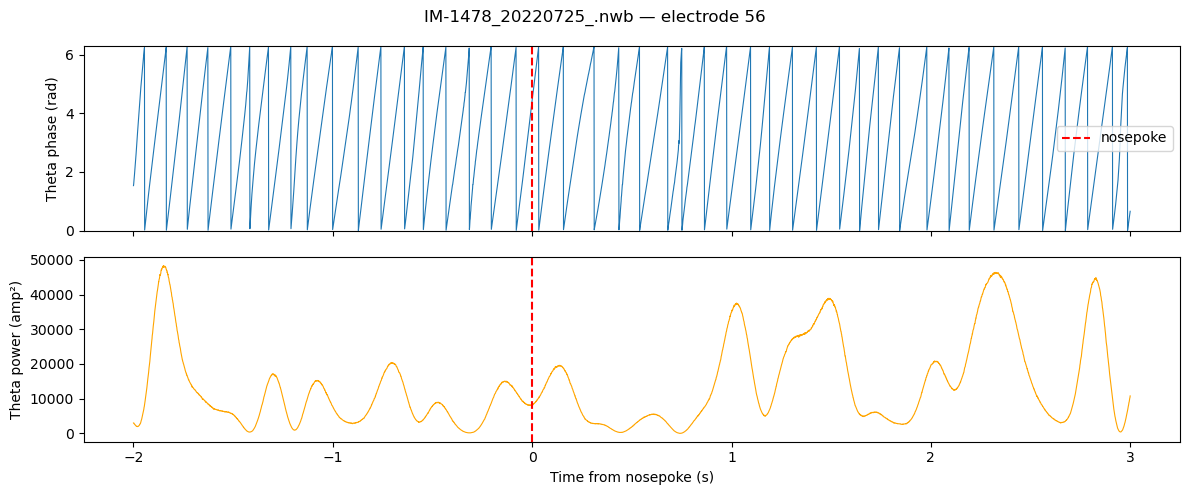

In [12]:
# Quick plot: theta phase and power for one electrode over a 5-second window
from spyglass_hexmaze.hex_maze_behavior import HexMazeBlock

# Grab a nosepoke time as a reference point
poke_intervals = (HexMazeBlock.Trial & {"nwb_file_name": check_nwb}).fetch("poke_interval")
poke_time = poke_intervals[5][0]  # end of trial 5 (nosepoke)
t0, t1 = poke_time - 2, poke_time + 3

# Pick the first electrode column for plotting
electrode_col = phase_df.columns[0]

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

window_phase = phase_df.loc[t0:t1, electrode_col]
window_power = power_df.loc[t0:t1, electrode_col]

axes[0].plot(window_phase.index - poke_time, window_phase, lw=0.8)
axes[0].axvline(0, color="r", linestyle="--", label="nosepoke")
axes[0].set_ylabel("Theta phase (rad)")
axes[0].set_ylim(0, 2 * np.pi)
axes[0].legend()

axes[1].plot(window_power.index - poke_time, window_power, lw=0.8, color="orange")
axes[1].axvline(0, color="r", linestyle="--")
axes[1].set_ylabel("Theta power (amp²)")
axes[1].set_xlabel("Time from nosepoke (s)")

fig.suptitle(f"{check_nwb} — {electrode_col}")
plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Check theta power correlation across electrodes for each populated session.
# High correlation (r > 0.9) means any subset is fine for power filtering.
# Outlier electrodes or clusters suggest layer differences or bad channels.

populated_sessions = (HexMazeThetaV1()).fetch("nwb_file_name")

n_sessions = len(populated_sessions)
fig, axes = plt.subplots(1, n_sessions, figsize=(5 * n_sessions, 4))
if n_sessions == 1:
    axes = [axes]

for ax, nwb in zip(axes, sorted(populated_sessions)):
    power_df = (HexMazeThetaV1() & {"nwb_file_name": nwb}).fetch1_theta_power()

    corr = power_df.corr()

    sns.heatmap(
        corr,
        ax=ax,
        vmin=0,
        vmax=1,
        cmap="viridis",
        square=True,
        xticklabels=False,
        yticklabels=False,
        cbar_kws={"shrink": 0.7},
    )
    # Summarize: mean off-diagonal correlation
    n = corr.shape[0]
    mean_corr = (corr.values.sum() - n) / (n * (n - 1))
    ax.set_title(f"{nwb.replace('IM-1478_', '').replace('_.nwb', '')}\nmean r={mean_corr:.2f}, n={n} electrodes")

plt.suptitle("Theta power correlation across electrodes", y=1.02)
plt.tight_layout()
plt.show()

[2026-04-27 15:31:21,693][WARNING]: Skipped checksum for file with hash: 414788ed-c367-3135-1ef9-6b3d8ebe16f6, and path: /stelmo/nwb/analysis/IM-1478_20220719/IM-1478_20220719_P0VHPC4NKY.nwb
[2026-04-27 15:31:21,703][WARNING]: Skipped checksum for file with hash: 414788ed-c367-3135-1ef9-6b3d8ebe16f6, and path: /stelmo/nwb/analysis/IM-1478_20220719/IM-1478_20220719_P0VHPC4NKY.nwb
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extens

## Theta power correlation across electrodes

For each session: load theta power, subsample heavily (every 50th point → ~20 Hz effective rate), and plot the electrode-electrode correlation matrix. Run one cell at a time — each load from disk takes a while.

High mean r (> 0.9) → safe to average all electrodes for power filtering.  
Block structure → electrodes are in different layers/regio

In [4]:
import datajoint as dj
import numpy as np
import pandas as pd

import spyglass.common as sgc
import spyglass.lfp as lfp
import spyglass.spikesorting.v1 as sgs
from spyglass.lfp.analysis.v1.lfp_band import LFPBandV1, LFPBandSelection

from spyglass_hexmaze.hex_maze_decoding import HexMazeThetaV1
import matplotlib.pyplot as plt
import seaborn as sns


display(HexMazeThetaV1())

def plot_power_corr(nwb_file_name, subsample=50):
    """Load theta power for one session, subsample, and plot correlation heatmap.
    
    subsample=50 keeps every 50th timepoint (~20 Hz effective rate), which is
    plenty for a correlation check and avoids loading tens of millions of rows.
    """
    power_df = (HexMazeThetaV1() & {"nwb_file_name": nwb_file_name}).fetch1_theta_power()
    power_sub = power_df.iloc[::subsample]

    corr = power_sub.corr()
    n = corr.shape[0]
    mean_corr = (corr.values.sum() - n) / (n * (n - 1))

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        corr, ax=ax, vmin=0, vmax=1, cmap="viridis",
        square=True, xticklabels=False, yticklabels=False,
        cbar_kws={"shrink": 0.7},
    )
    session = nwb_file_name.replace("IM-1478_", "").replace("_.nwb", "")
    ax.set_title(f"{session}  |  mean r={mean_corr:.2f}, n={n} electrodes")
    plt.tight_layout()
    plt.show()
    print(f"Loaded {len(power_df):,} timepoints, used {len(power_sub):,} for correlation")

/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-04-27 17:09:02,652][INFO]: DataJoint 0.14.6 connected to scrater@lmf-db.cin.ucsf.edu:3306
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-fiber-photometry': 
 ndx-fiber-photometry defines OpticalFiber.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel.
ndx-fiber-photometry defines ExcitationSource.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel.
ndx-fiber-photometry defines Photodetector.model as an attribute (dtype: text) while the core 

lfp_merge_id,filter_name descriptive name of this filter,filter_sampling_rate sampling rate for this filter,nwb_file_name name of the NWB file,target_interval_list_name descriptive name of this interval list,lfp_band_sampling_rate the sampling rate for this band,analysis_file_name name of the file,analytic_signal_object_id real+imag parts of Hilbert transform,"theta_phase_object_id instantaneous phase [0, 2π] in radians",theta_power_object_id instantaneous power (amplitude²)
578f3c15-ce09-b3e8-39e8-f06120fe8570,Theta 5-11 Hz,1000,IM-1478_20220727_.nwb,00_r1,1000,IM-1478_20220727_R38TB49GRY.nwb,dc07fcfd-357e-4b9d-b32b-7fb4d0216921,de60167a-aa17-45ab-aa88-90919020bd10,5235e3c2-2090-4c24-bc53-d4f1fe12a455
595c99be-c433-697a-07a1-8727c8aacbc1,Theta 5-11 Hz,1000,IM-1478_20220720_.nwb,00_r1,1000,IM-1478_20220720_M4B8NY7XMF.nwb,a689ffcf-a0ca-4368-9ffc-df66312e71b1,80f8a467-d1c4-450e-b900-89a9c2d58103,8303f3cf-7531-4ec4-9de8-ef056035dbad
9bd18c6f-4cf3-ac6b-2550-85fd5feadb05,Theta 5-11 Hz,1000,IM-1478_20220719_.nwb,00_r1,1000,IM-1478_20220719_P0VHPC4NKY.nwb,048d60d1-145b-47f5-9c20-d9d5fbfbf4b1,b5dfa8bd-df84-4fd0-8282-181074e34a8c,c5795c90-9431-49e4-b4a9-f555da36bac0
adedefb8-14fb-e338-1756-c98f95fcb548,Theta 5-11 Hz,1000,IM-1478_20220724_.nwb,00_r1,1000,IM-1478_20220724_SCG7CSC540.nwb,da5e22c6-71a9-449a-a186-7af7c3107627,26f4de67-a564-4e84-9f01-83c854c3b1bd,364dbb6d-62a9-4f1f-a904-49640842687b
cd702cb8-e5da-215c-8baa-b17e379ee730,Theta 5-11 Hz,1034,IM-1478_20220726_.nwb,00_r1,1034,IM-1478_20220726_JDBFUU27FU.nwb,a0917833-949e-4358-8230-9ddb16997bd1,f94330af-9cad-4697-9454-39d8b95521fd,afd16f64-b158-4215-9528-d5f746ae0ab8
ffdc1372-d44c-8381-1fb9-e81595e2a911,Theta 5-11 Hz,1000,IM-1478_20220725_.nwb,00_r1,1000,IM-1478_20220725_IMSEN7F3KS.nwb,9ce0ffc5-a5dc-416b-b0cc-beac91d0451a,6932cdad-a4c7-4c9d-bd9a-a8a88e45610e,1a4a0c74-7034-416f-bfde-5b2f5c86592d


[2026-04-27 15:52:20,602][WARNING]: Skipped checksum for file with hash: a11a4b09-bd10-28f0-3fb1-7caf2efb8cde, and path: /stelmo/nwb/analysis/IM-1478_20220720/IM-1478_20220720_M4B8NY7XMF.nwb
[2026-04-27 15:52:20,609][WARNING]: Skipped checksum for file with hash: a11a4b09-bd10-28f0-3fb1-7caf2efb8cde, and path: /stelmo/nwb/analysis/IM-1478_20220720/IM-1478_20220720_M4B8NY7XMF.nwb
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extens

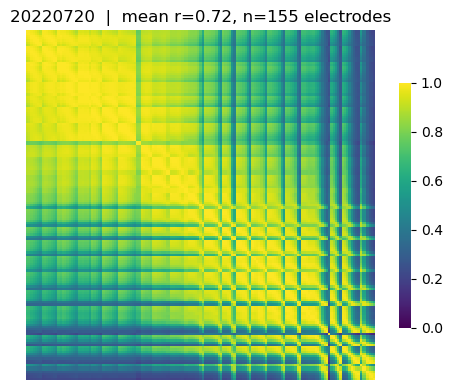

Loaded 6,769,783 timepoints, used 135,396 for correlation


In [11]:
plot_power_corr("IM-1478_20220720_.nwb")

## Theta phase consistency across electrodes

Two analyses:
1. **Circular coherence matrix** — for each electrode pair, `|mean(exp(i*(φ_a − φ_b)))|`. Value of 1 = always in the same phase relationship; 0 = random. This is the correct measure for circular data (Pearson correlation is not).
2. **Phase offset vs. depth** — pick a reference electrode, compute each electrode's mean phase offset relative to it (c

In [ ]:
def plot_phase_coherence(nwb_file_name, subsample=50):
    """Circular coherence matrix across electrodes.

    For each pair (a, b): coherence = |mean(exp(i*(phase_a - phase_b)))|
    Computed efficiently via complex matrix multiplication.
    """
    phase_df = (HexMazeThetaV1() & {"nwb_file_name": nwb_file_name}).fetch1_theta_phase()
    phase_sub = phase_df.iloc[::subsample].values  # shape: (n_times, n_electrodes)

    # Complex exponential form — lets us do the whole matrix in one shot
    z = np.exp(1j * phase_sub)  # (n_times, n_electrodes)
    coherence = np.abs(z.T @ np.conj(z)) / len(phase_sub)  # (n_electrodes, n_electrodes)
    coherence_df = pd.DataFrame(coherence, index=phase_df.columns, columns=phase_df.columns)

    n = coherence_df.shape[0]
    mean_coh = (coherence.sum() - n) / (n * (n - 1))

    g = sns.clustermap(
        coherence_df,
        vmin=0, vmax=1, cmap="viridis",
        figsize=(8, 8),
        xticklabels=True, yticklabels=True,
    )
    g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=6, rotation=90)
    g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=6, rotation=0)
    session = nwb_file_name.replace("IM-1478_", "").replace("_.nwb", "")
    g.figure.suptitle(f"{session} — theta phase coherence (clustered)  |  mean={mean_coh:.2f}", y=1.01)
    plt.show()

    ordered_cols = coherence_df.columns[g.dendrogram_col.reordered_ind].tolist()
    print("Electrode order after clustering:")
    print(ordered_cols)
    
plot_phase_coherence("IM-1478_20220719_.nwb")

In [5]:
def plot_phase_vs_depth(nwb_file_name, ref_electrode_id=None, subsample=50):
    """Plot mean theta phase offset per electrode, organized by probe geometry.

    Uses probe_shank (color) and probe_electrode (y-axis) from the NWB electrode
    table as a proxy for spatial position across the recording array.
    """
    phase_df = (HexMazeThetaV1() & {"nwb_file_name": nwb_file_name}).fetch1_theta_phase()
    phase_sub = phase_df.iloc[::subsample]

    if ref_electrode_id is None:
        ref_electrode_id = phase_sub.columns[0]
    ref_phase = phase_sub[ref_electrode_id].values

    # Circular mean phase offset for each electrode relative to reference
    phase_offsets = {}
    for elec_id in phase_sub.columns:
        diff = phase_sub[elec_id].values - ref_phase
        phase_offsets[elec_id] = np.angle(np.mean(np.exp(1j * diff)))

    # phase_df columns are electrode 'name' strings (e.g. 'electrode 250') from sgc.Electrode
    elec_table = pd.DataFrame(
        (sgc.Electrode & {"nwb_file_name": nwb_file_name}).fetch(as_dict=True)
    )[["name", "probe_shank", "probe_electrode"]].set_index("name")

    offset_series = pd.Series(phase_offsets, name="phase_offset_deg").apply(np.degrees)
    merged = elec_table.join(offset_series, how="inner")

    fig, ax = plt.subplots(figsize=(5, 7))
    shanks = sorted(merged["probe_shank"].unique())
    colors = plt.cm.tab10(np.linspace(0, 1, len(shanks)))
    for shank, color in zip(shanks, colors):
        grp = merged[merged["probe_shank"] == shank]
        ax.scatter(grp["phase_offset_deg"], grp["probe_electrode"],
                   color=color, s=40, alpha=0.8, label=f"shank {shank}")

    ax.axvline(0, color="gray", linestyle="--", lw=0.8)
    ax.set_xlabel(f"Mean phase offset from electrode {ref_electrode_id} (degrees)")
    ax.set_ylabel("probe_electrode")
    session = nwb_file_name.replace("IM-1478_", "").replace("_.nwb", "")
    ax.set_title(f"{session} — theta phase offset vs. probe geometry")
    ax.legend(fontsize=7, ncol=2)
    plt.tight_layout()
    plt.show()

    return merged.sort_values(["probe_shank", "probe_electrode"])

[2026-04-27 17:55:31,822][WARNING]: Skipped checksum for file with hash: 414788ed-c367-3135-1ef9-6b3d8ebe16f6, and path: /stelmo/nwb/analysis/IM-1478_20220719/IM-1478_20220719_P0VHPC4NKY.nwb
[2026-04-27 17:55:31,828][WARNING]: Skipped checksum for file with hash: 414788ed-c367-3135-1ef9-6b3d8ebe16f6, and path: /stelmo/nwb/analysis/IM-1478_20220719/IM-1478_20220719_P0VHPC4NKY.nwb


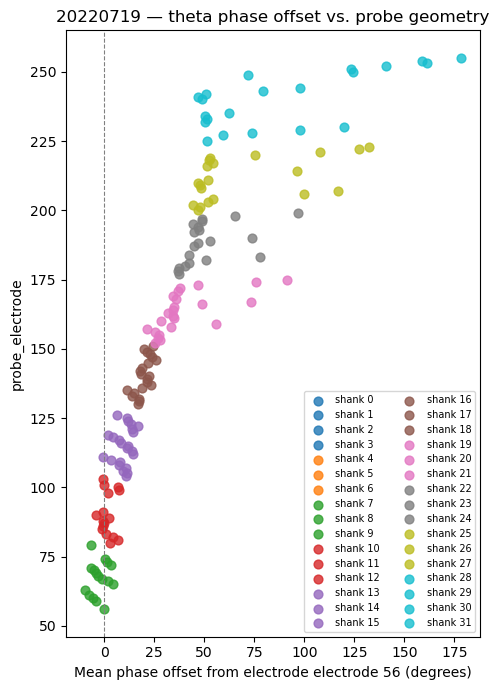

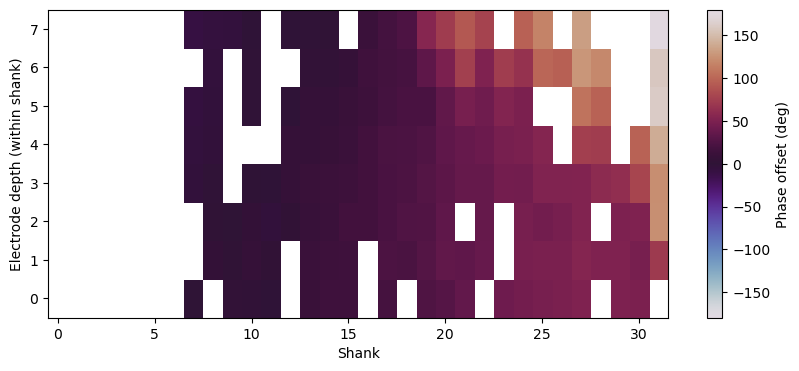

In [41]:
subsample = 50

phase_df = (HexMazeThetaV1() & {"nwb_file_name": nwb_file_name}).fetch1_theta_phase()
phase_sub = phase_df.iloc[::subsample]

ref_electrode_id = phase_sub.columns[0]
ref_phase = phase_sub[ref_electrode_id].values

# Circular mean phase offset for each electrode relative to reference
phase_offsets = {}
for elec_id in phase_sub.columns:
    diff = phase_sub[elec_id].values - ref_phase
    phase_offsets[elec_id] = np.angle(np.mean(np.exp(1j * diff)))

# phase_df columns are electrode 'name' strings (e.g. 'electrode 250') from sgc.Electrode
elec_table = pd.DataFrame(
    (sgc.Electrode & {"nwb_file_name": nwb_file_name}).fetch(as_dict=True)
)[["name", "probe_shank", "probe_electrode"]].set_index("name")

offset_series = pd.Series(phase_offsets, name="phase_offset_deg").apply(np.degrees)
offset_series.index = offset_series.index.str.split().str[-1]  # '56', '59', ...
merged = elec_table.join(offset_series)

electrodes_per_shank = merged.groupby('probe_shank')['probe_electrode'].nunique().iloc[0]
merged['shank_electrode'] = merged['probe_electrode'] % electrodes_per_shank

fig, ax = plt.subplots(figsize=(5, 7))
shanks = sorted(merged["probe_shank"].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(shanks)))
for shank, color in zip(shanks, colors):
    grp = merged[merged["probe_shank"] == shank]
    ax.scatter(grp["phase_offset_deg"], grp["probe_electrode"],
                color=color, s=40, alpha=0.8, label=f"shank {shank}")

ax.axvline(0, color="gray", linestyle="--", lw=0.8)
ax.set_xlabel(f"Mean phase offset from electrode {ref_electrode_id} (degrees)")
ax.set_ylabel("probe_electrode")
session = nwb_file_name.replace("IM-1478_", "").replace("_.nwb", "")
ax.set_title(f"{session} — theta phase offset vs. probe geometry")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

pivot = merged.pivot(index='shank_electrode', columns='probe_shank', values='phase_offset_deg')
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(pivot, aspect='auto', cmap='twilight', vmin=-180, vmax=180)
ax.invert_yaxis()
ax.set_xlabel('Shank')
ax.set_ylabel('Electrode depth (within shank)')
plt.colorbar(im, ax=ax, label='Phase offset (deg)')

[2026-04-27 18:02:23,371][WARNING]: Skipped checksum for file with hash: 414788ed-c367-3135-1ef9-6b3d8ebe16f6, and path: /stelmo/nwb/analysis/IM-1478_20220719/IM-1478_20220719_P0VHPC4NKY.nwb
[2026-04-27 18:02:23,381][WARNING]: Skipped checksum for file with hash: 414788ed-c367-3135-1ef9-6b3d8ebe16f6, and path: /stelmo/nwb/analysis/IM-1478_20220719/IM-1478_20220719_P0VHPC4NKY.nwb


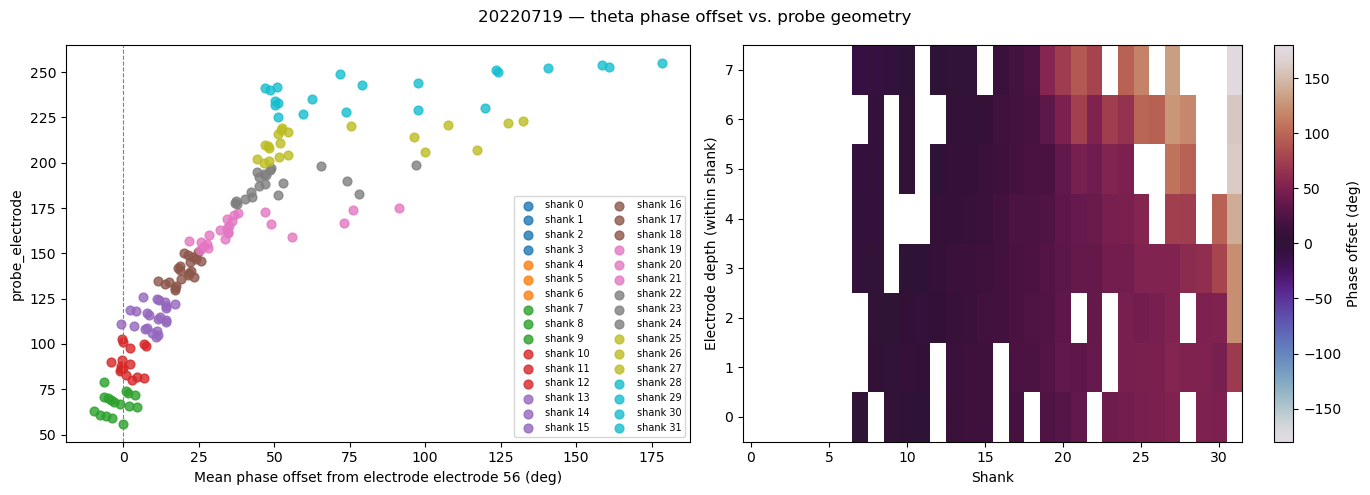

[2026-04-27 18:02:53,194][WARNING]: Skipped checksum for file with hash: a11a4b09-bd10-28f0-3fb1-7caf2efb8cde, and path: /stelmo/nwb/analysis/IM-1478_20220720/IM-1478_20220720_M4B8NY7XMF.nwb
[2026-04-27 18:02:53,203][WARNING]: Skipped checksum for file with hash: a11a4b09-bd10-28f0-3fb1-7caf2efb8cde, and path: /stelmo/nwb/analysis/IM-1478_20220720/IM-1478_20220720_M4B8NY7XMF.nwb


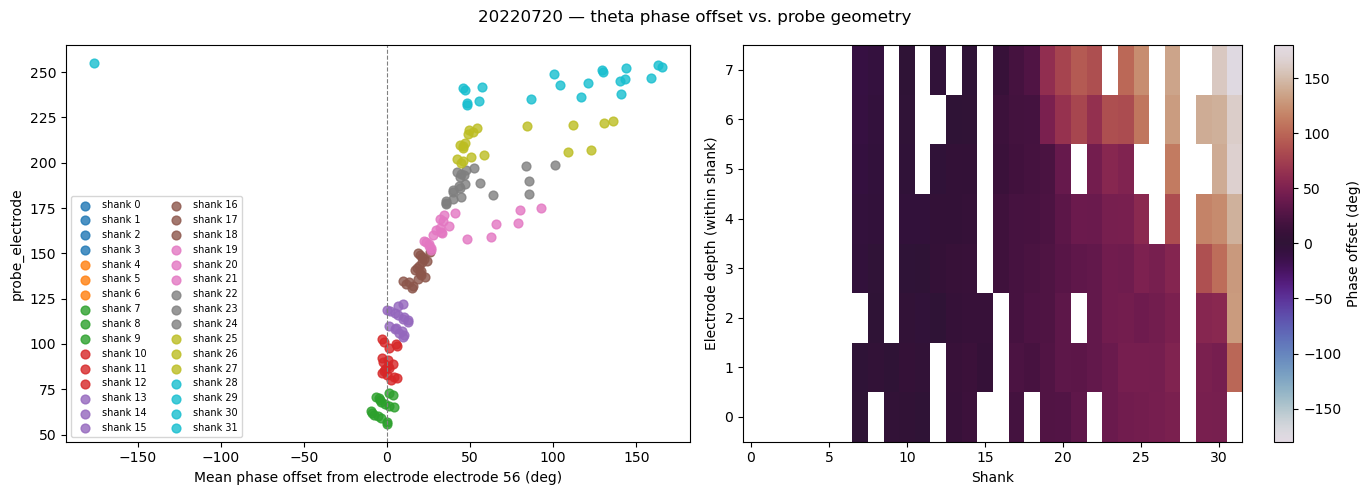

[2026-04-27 18:03:19,996][WARNING]: Skipped checksum for file with hash: 4fa319a7-77d0-7dc6-6409-76f43da7569c, and path: /stelmo/nwb/analysis/IM-1478_20220724/IM-1478_20220724_SCG7CSC540.nwb
[2026-04-27 18:03:20,006][WARNING]: Skipped checksum for file with hash: 4fa319a7-77d0-7dc6-6409-76f43da7569c, and path: /stelmo/nwb/analysis/IM-1478_20220724/IM-1478_20220724_SCG7CSC540.nwb


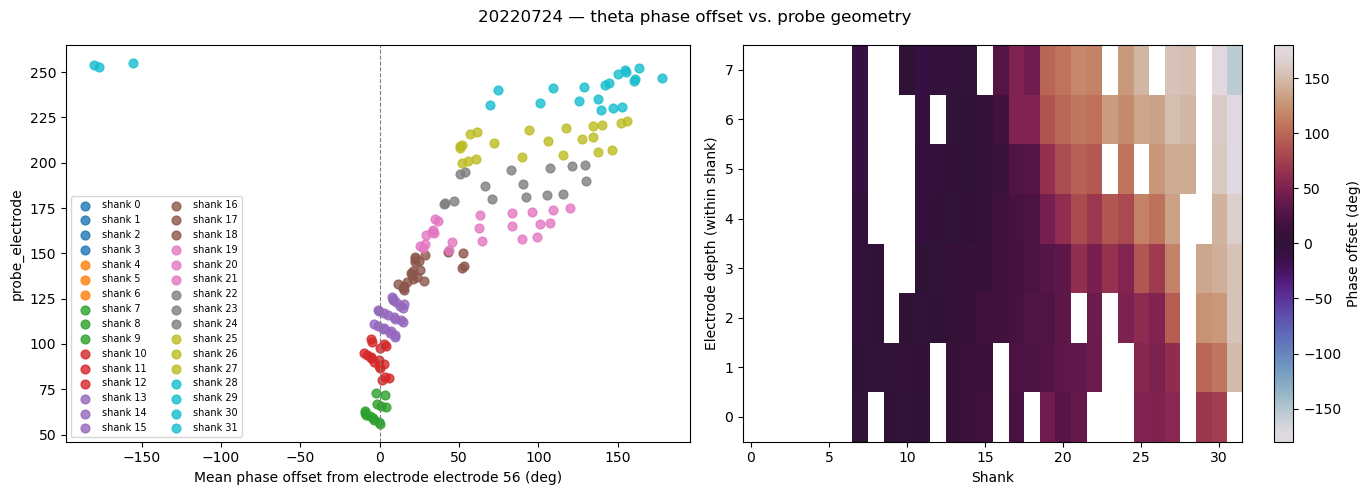

[2026-04-27 18:05:01,058][WARNING]: Skipped checksum for file with hash: e579349a-10f1-9245-8daf-740f093ecb2a, and path: /stelmo/nwb/analysis/IM-1478_20220725/IM-1478_20220725_IMSEN7F3KS.nwb
[2026-04-27 18:05:01,063][WARNING]: Skipped checksum for file with hash: e579349a-10f1-9245-8daf-740f093ecb2a, and path: /stelmo/nwb/analysis/IM-1478_20220725/IM-1478_20220725_IMSEN7F3KS.nwb
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extens

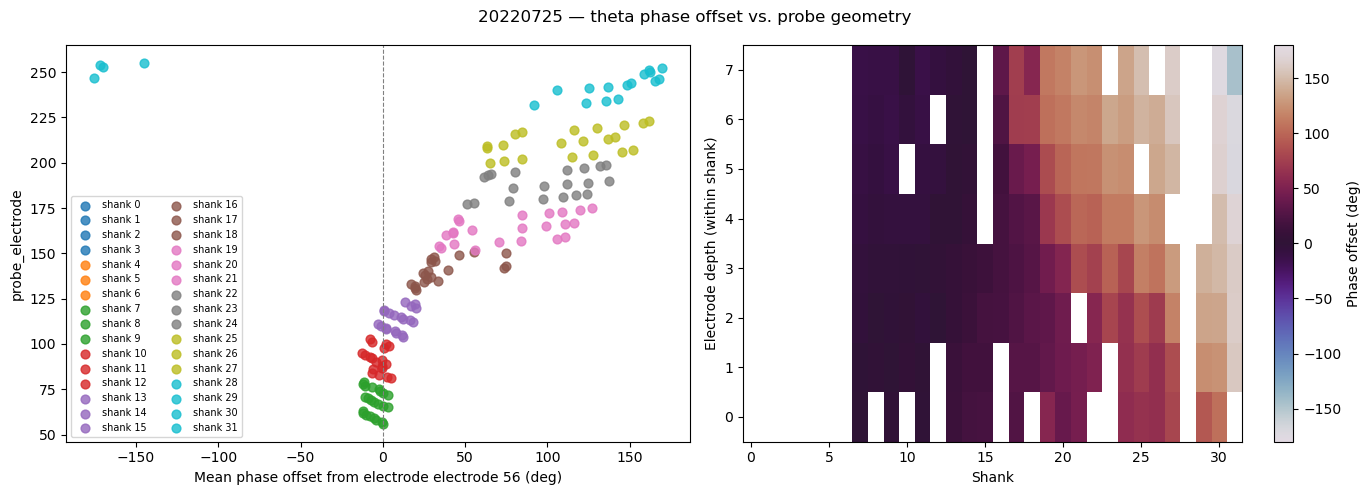

[2026-04-27 18:09:07,439][WARNING]: Skipped checksum for file with hash: bd78b08e-5d17-2e69-95c7-09154d00f071, and path: /stelmo/nwb/analysis/IM-1478_20220726/IM-1478_20220726_JDBFUU27FU.nwb
[2026-04-27 18:09:07,449][WARNING]: Skipped checksum for file with hash: bd78b08e-5d17-2e69-95c7-09154d00f071, and path: /stelmo/nwb/analysis/IM-1478_20220726/IM-1478_20220726_JDBFUU27FU.nwb
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extens

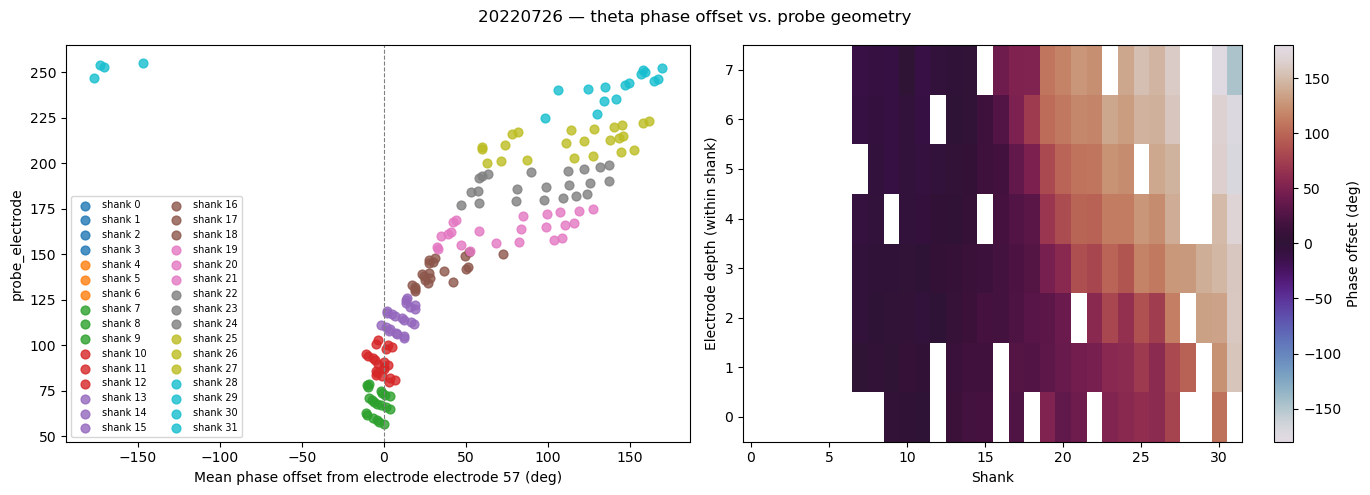

[2026-04-27 18:09:30,862][WARNING]: Skipped checksum for file with hash: 172e3449-6037-8ef7-4c87-565071a18f9e, and path: /stelmo/nwb/analysis/IM-1478_20220727/IM-1478_20220727_R38TB49GRY.nwb
[2026-04-27 18:09:30,872][WARNING]: Skipped checksum for file with hash: 172e3449-6037-8ef7-4c87-565071a18f9e, and path: /stelmo/nwb/analysis/IM-1478_20220727/IM-1478_20220727_R38TB49GRY.nwb
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extens

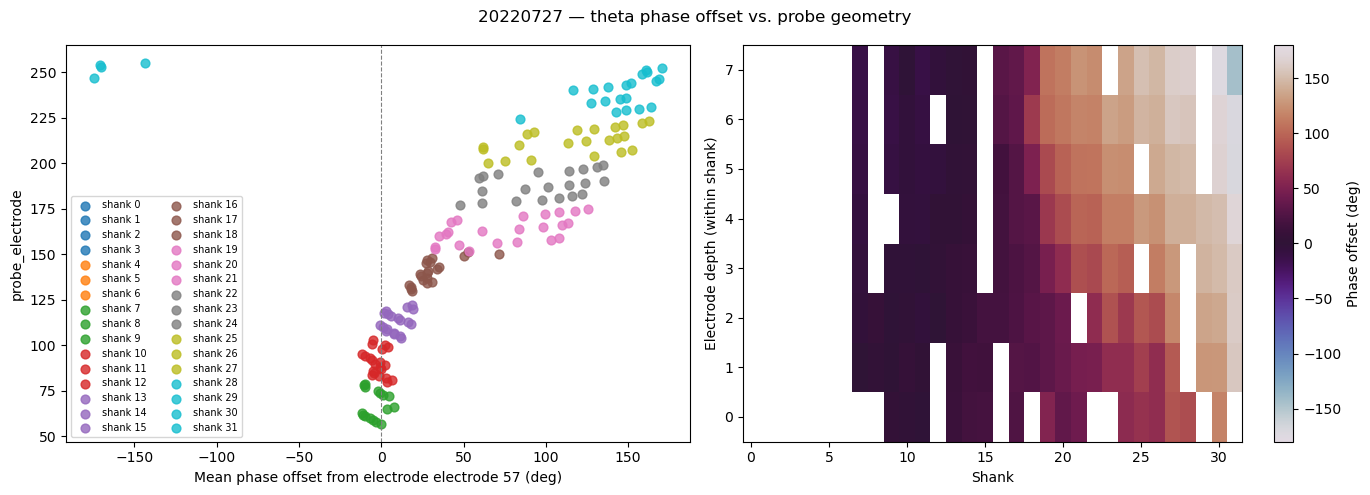

In [ ]:
restriction = 'nwb_file_name LIKE "IM-1478%"'
nwb_files = (HexMazeThetaV1() & restriction).fetch("nwb_file_name")

for nwb_file_name in nwb_files:
    subsample = 50

    phase_df = (HexMazeThetaV1() & {"nwb_file_name": nwb_file_name}).fetch1_theta_phase()
    phase_sub = phase_df.iloc[::subsample]

    ref_electrode_id = phase_sub.columns[0]
    ref_phase = phase_sub[ref_electrode_id].values

    phase_offsets = {}
    for elec_id in phase_sub.columns:
        diff = phase_sub[elec_id].values - ref_phase
        phase_offsets[elec_id] = np.angle(np.mean(np.exp(1j * diff)))

    elec_table = pd.DataFrame(
        (sgc.Electrode & {"nwb_file_name": nwb_file_name}).fetch(as_dict=True)
    )[["name", "probe_shank", "probe_electrode"]].set_index("name")

    offset_series = pd.Series(phase_offsets, name="phase_offset_deg").apply(np.degrees)
    offset_series.index = offset_series.index.str.split().str[-1]
    merged = elec_table.join(offset_series)

    electrodes_per_shank = merged.groupby('probe_shank')['probe_electrode'].nunique().iloc[0]
    merged['shank_electrode'] = merged['probe_electrode'] % electrodes_per_shank

    session = nwb_file_name.replace("IM-1478_", "").replace("_.nwb", "")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter: offset vs probe_electrode, colored by shank
    ax = axes[0]
    shanks = sorted(merged["probe_shank"].unique())
    colors = plt.cm.tab10(np.linspace(0, 1, len(shanks)))
    for shank, color in zip(shanks, colors):
        grp = merged[merged["probe_shank"] == shank]
        ax.scatter(grp["phase_offset_deg"], grp["probe_electrode"],
           color=color, s=40, alpha=0.8, label=f"shank {shank}")
    ax.axvline(0, color="gray", linestyle="--", lw=0.8)
    ax.set_xlabel(f"Mean phase offset from electrode {ref_electrode_id} (deg)")
    ax.set_ylabel("probe_electrode")
    ax.legend(fontsize=7, ncol=2)
    
    # Heatmap
    ax = axes[1]
    pivot = merged.pivot(index='shank_electrode', columns='probe_shank', values='phase_offset_deg')
    im = ax.imshow(pivot, aspect='auto', cmap='twilight', vmin=-180, vmax=180)
    ax.invert_yaxis()
    ax.set_xlabel('Shank')
    ax.set_ylabel('Electrode depth (within shank)')
    plt.colorbar(im, ax=ax, label='Phase offset (deg)')

    fig.suptitle(f"{session} — theta phase offset vs. probe geometry")
    plt.tight_layout()
    plt.show()


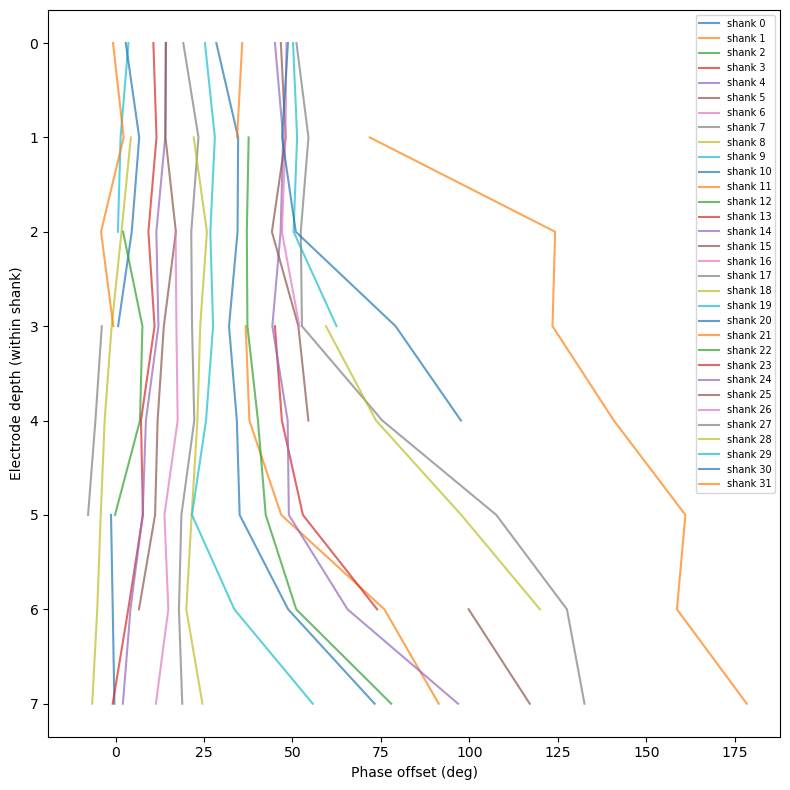

In [35]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))
for shank, grp in merged.groupby('probe_shank'):
    ax.plot(grp['phase_offset_deg'], grp['shank_electrode'], label=f'shank {shank}', alpha=0.7)
ax.invert_yaxis()  # deeper electrodes down
ax.set_xlabel('Phase offset (deg)')
ax.set_ylabel('Electrode depth (within shank)')
ax.legend(fontsize=7)
plt.tight_layout()



[2026-04-27 21:09:01,500][WARNING]: Skipped checksum for file with hash: 414788ed-c367-3135-1ef9-6b3d8ebe16f6, and path: /stelmo/nwb/analysis/IM-1478_20220719/IM-1478_20220719_P0VHPC4NKY.nwb
[2026-04-27 21:09:01,511][WARNING]: Skipped checksum for file with hash: 414788ed-c367-3135-1ef9-6b3d8ebe16f6, and path: /stelmo/nwb/analysis/IM-1478_20220719/IM-1478_20220719_P0VHPC4NKY.nwb


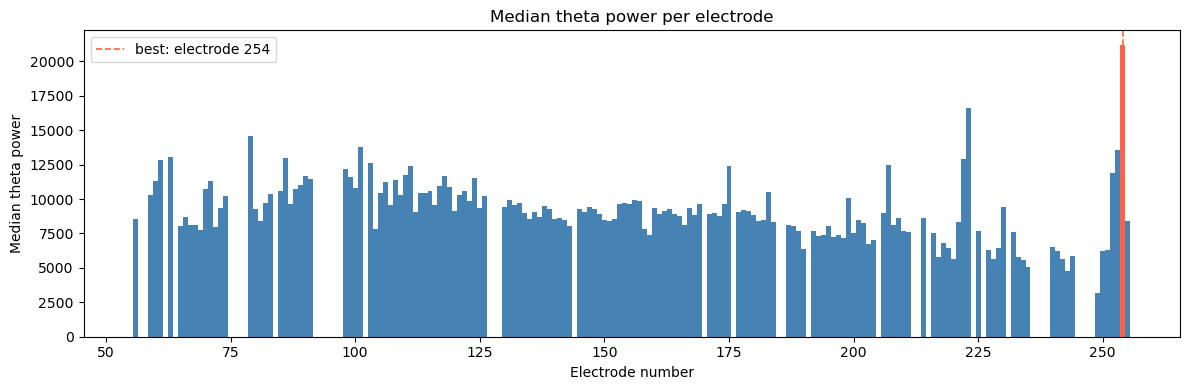

Best electrode: electrode 254  (median power = 21196.1096)


In [16]:
nwb_file_name = "IM-1478_20220719_.nwb"

power_df = (HexMazeThetaV1 & {"nwb_file_name": nwb_file_name}).fetch1_theta_power()
power_df.head()

# Plot median theta power per electrode — useful for identifying the best reference channel.
# Electrode numbers are extracted from column names like "electrode 57".
median_power = power_df.median()
electrode_nums = [int(col.split()[-1]) for col in median_power.index]
best_col = median_power.idxmax()
best_num = int(best_col.split()[-1])

fig, ax = plt.subplots(figsize=(12, 4))
colors = ["tomato" if col == best_col else "steelblue" for col in median_power.index]
ax.bar(electrode_nums, median_power.values, color=colors, width=1.0)
ax.axvline(best_num, color="tomato", linestyle="--", linewidth=1.2, label=f"best: electrode {best_num}")
ax.set_xlabel("Electrode number")
ax.set_ylabel("Median theta power")
ax.set_title(f"Median theta power per electrode")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Best electrode: {best_col}  (median power = {median_power[best_col]:.4f})")

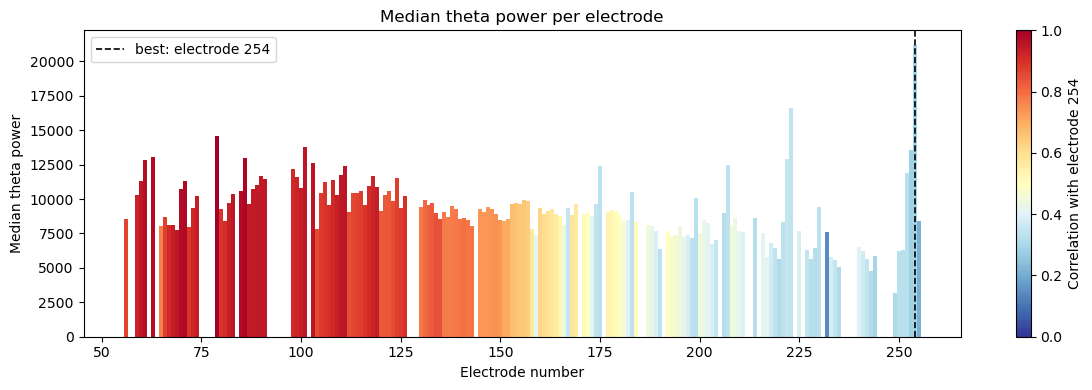

Best electrode: electrode 254  (median power = 21196.1096)


In [21]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

median_power = power_df.median()
best_col = median_power.idxmax()
best_num = int(best_col.split()[-1])
electrode_nums = [int(col.split()[-1]) for col in median_power.index]

# Pearson correlation of each electrode with the best electrode
corr_with_best = power_df.corr()["electrode 79"]

cmap = cm.RdYlBu_r
norm = mcolors.Normalize(vmin=0, vmax=1)
colors = [cmap(norm(corr_with_best[col])) for col in median_power.index]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(electrode_nums, median_power.values, color=colors, width=1.0)
ax.axvline(best_num, color='black', linestyle='--', linewidth=1.2, label=f'best: electrode {best_num}')

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label=f'Correlation with electrode {best_num}')

ax.set_xlabel('Electrode number')
ax.set_ylabel('Median theta power')
ax.set_title(f'Median theta power per electrode')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Best electrode: {best_col}  (median power = {median_power[best_col]:.4f})')


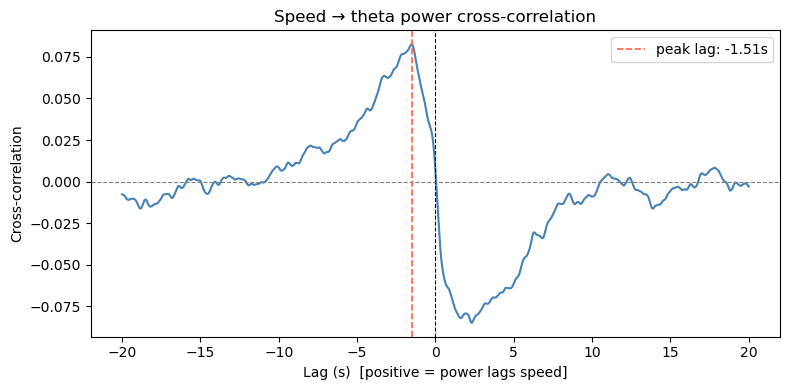

Peak correlation 0.083 at lag -1.512s


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore
from scipy.signal import correlate

# Fetch decode dataframe (has 'speed' column) and theta power
from spyglass_hexmaze.hex_maze_decoding import HexMazeDecodedPosition
decode_df = (HexMazeDecodedPosition & key).fetch1_dataframe()

# Align speed to theta power timestamps via nearest-neighbor merge
power_series = power_df["electrode 254"]  # use your best electrode
speed_series = decode_df["speed"].dropna()

# Reindex speed onto power timestamps
speed_aligned = speed_series.reindex(power_series.index, method="nearest", tolerance=0.05)

# Use the already-aligned, z-scored signals (drop NaNs at same indices)
valid = speed_aligned.notna()
x = zscore(speed_aligned[valid].values)
y = zscore(power_series[valid].values)

# Cross-correlation
lags = np.arange(-(len(x) - 1), len(x))
xcorr = correlate(y, x, mode="full") / len(x)  # normalize by n

# Convert lags from samples to seconds
dt = float(np.median(np.diff(power_series.index)))
lag_seconds = lags * dt

# Trim to a reasonable window (e.g. ±10 seconds)
window = 20
mask = np.abs(lag_seconds) <= window

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lag_seconds[mask], xcorr[mask], color="steelblue")
ax.axvline(0, color="black", linestyle="--", linewidth=0.8)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
peak_lag = lag_seconds[mask][np.argmax(xcorr[mask])]
ax.axvline(peak_lag, color="tomato", linestyle="--", linewidth=1.2, label=f"peak lag: {peak_lag:.2f}s")
ax.set_xlabel("Lag (s)  [positive = power lags speed]")
ax.set_ylabel("Cross-correlation")
ax.set_title(f"Speed → theta power cross-correlation")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Peak correlation {xcorr[mask].max():.3f} at lag {peak_lag:.3f}s")

